In [ ]:
# ==========================================================
# Daily Revenue Forecast using Prophet
# Forecast Horizon: Next 90 Days
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# ==========================================================
# 1. Load Dataset
# ==========================================================

data = pd.read_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\final_cleaned.csv"
)

df = data.copy()

# ==========================================================
# 2. Data Preparation
# ==========================================================

# Convert to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Train on historical data only
df = df[df['order_date'] < pd.Timestamp('2026-04-01')]

# ==========================================================
# 3. Daily Revenue Aggregation
# ==========================================================

daily_sales = (
    df.groupby('order_date')['net_amount']
      .sum()
      .reset_index()
)

# Prophet column names
daily_sales.columns = ['ds', 'y']

# Sort by date
daily_sales = daily_sales.sort_values('ds').reset_index(drop=True)

# ==========================================================
# 4. Build Prophet Model
# ==========================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

# Fit Model
model.fit(daily_sales)

# ==========================================================
# 5. Forecast Next 90 Days
# ==========================================================

future = model.make_future_dataframe(
    periods=90,
    freq='D'
)

forecast = model.predict(future)

# ==========================================================
# 6. Keep Important Columns
# ==========================================================

forecast_result = forecast[
    [
        'ds',
        'yhat',
        'yhat_lower',
        'yhat_upper',
        'trend'
    ]
]

print("\nForecast")
print(forecast_result.tail(10))

# ==========================================================
# 7. Combine Actual + Forecast
# ==========================================================

final_result = daily_sales.merge(
    forecast_result,
    on='ds',
    how='outer'
)

# ==========================================================
# 8. Export Forecast
# ==========================================================

final_result.to_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\forcast\daily_revenue_forecast.csv",
    index=False
)

print("\nForecast exported successfully.")


21:12:23 - cmdstanpy - INFO - Chain [1] start processing



Training Data
          ds             y
0 2025-04-02  1.042411e+08
1 2025-04-03  1.003444e+08
2 2025-04-04  8.884024e+07
3 2025-04-05  9.363554e+07
4 2025-04-06  1.016375e+08

Last 5 Days
            ds            y
359 2026-03-27  81118588.92
360 2026-03-28  98842565.40
361 2026-03-29  76661802.83
362 2026-03-30  88504618.75
363 2026-03-31  87019592.54


21:12:23 - cmdstanpy - INFO - Chain [1] done processing



Forecast
            ds          yhat    yhat_lower    yhat_upper         trend
444 2026-06-20  7.705712e+07  6.203907e+07  9.262324e+07  8.227741e+07
445 2026-06-21  7.547677e+07  6.042946e+07  9.071211e+07  8.223416e+07
446 2026-06-22  7.522349e+07  6.064006e+07  8.959740e+07  8.219090e+07
447 2026-06-23  7.724495e+07  6.193442e+07  9.197909e+07  8.214765e+07
448 2026-06-24  7.670127e+07  6.307512e+07  9.075428e+07  8.210440e+07
449 2026-06-25  7.686065e+07  6.373118e+07  9.072933e+07  8.206115e+07
450 2026-06-26  7.640873e+07  6.256775e+07  9.303595e+07  8.201790e+07
451 2026-06-27  7.728741e+07  6.300120e+07  9.216492e+07  8.197465e+07
452 2026-06-28  7.576386e+07  6.041636e+07  8.971411e+07  8.193140e+07
453 2026-06-29  7.556201e+07  6.124652e+07  8.992216e+07  8.188815e+07

Forecast exported successfully.


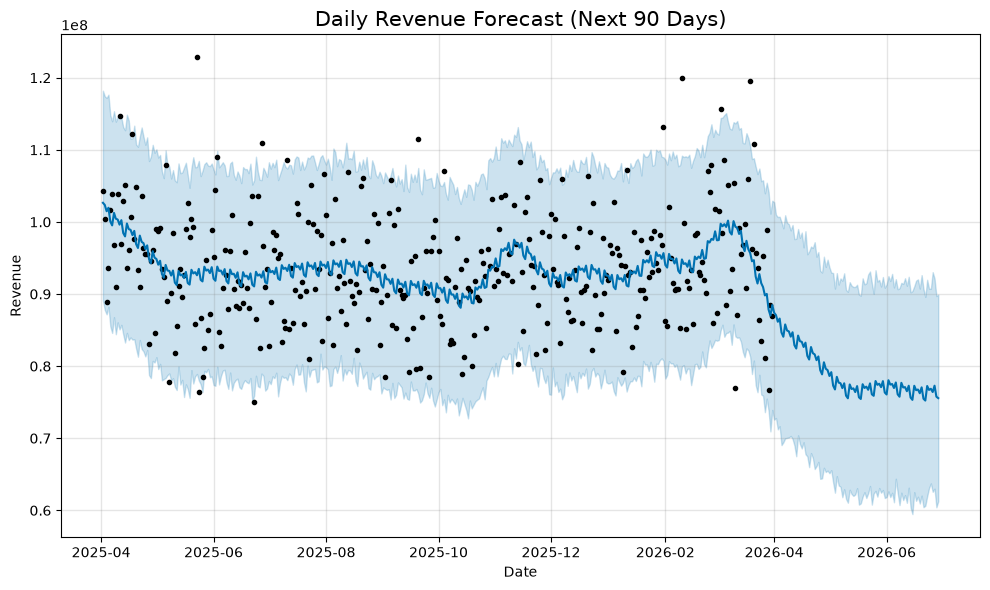

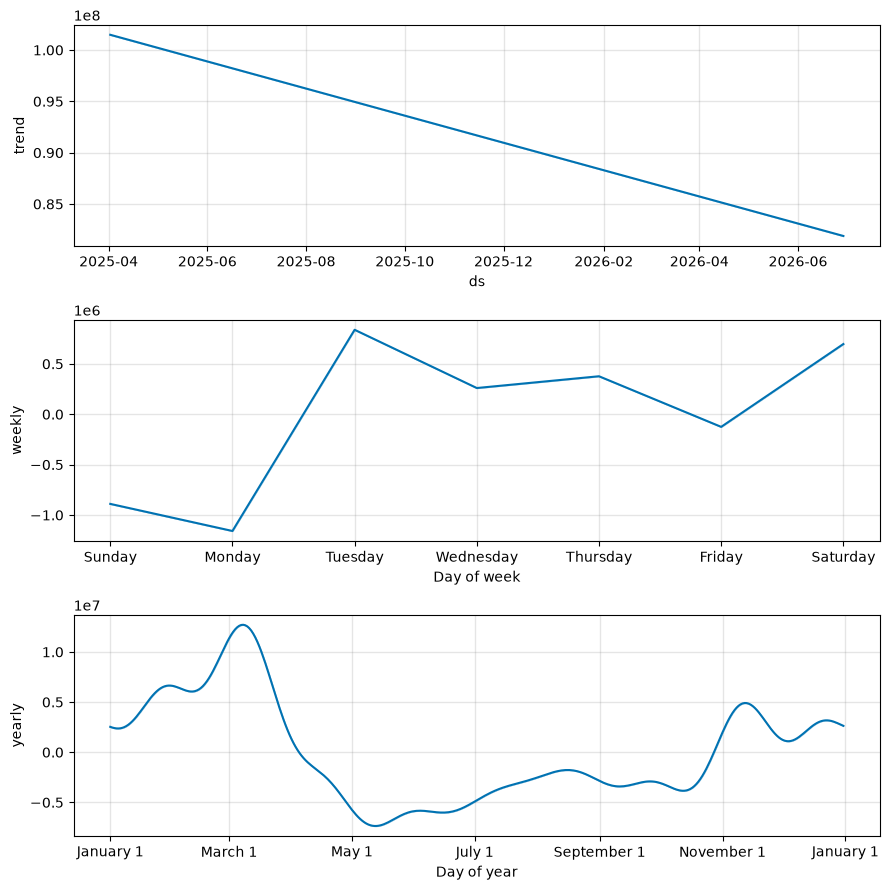

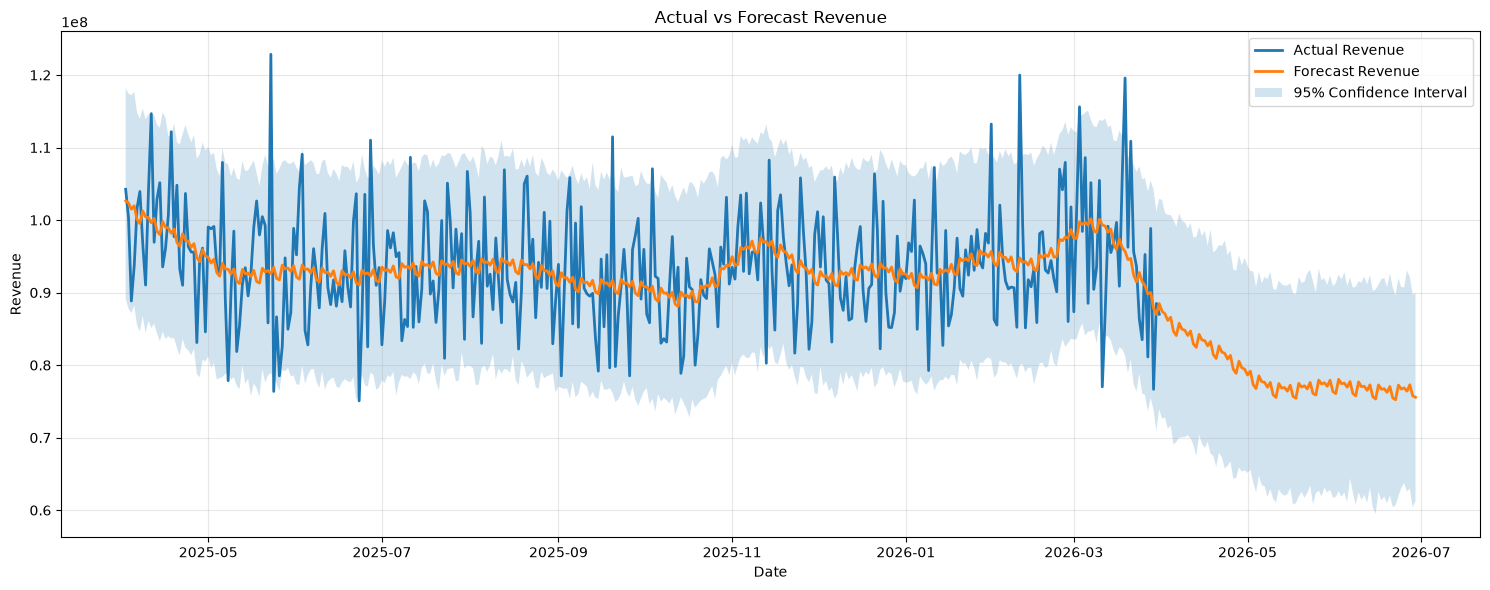


Next 90 Days Forecast
            ds          yhat    yhat_lower    yhat_upper         trend
364 2026-04-01  8.740944e+07  7.257171e+07  1.027442e+08  8.573744e+07
365 2026-04-02  8.707340e+07  7.280747e+07  1.009953e+08  8.569419e+07
366 2026-04-03  8.615475e+07  7.122778e+07  1.006788e+08  8.565094e+07
367 2026-04-04  8.659532e+07  7.166661e+07  1.007179e+08  8.560769e+07
368 2026-04-05  8.466154e+07  6.904450e+07  9.997359e+07  8.556444e+07
..         ...           ...           ...           ...           ...
449 2026-06-25  7.686065e+07  6.373118e+07  9.072933e+07  8.206115e+07
450 2026-06-26  7.640873e+07  6.256775e+07  9.303595e+07  8.201790e+07
451 2026-06-27  7.728741e+07  6.300120e+07  9.216492e+07  8.197465e+07
452 2026-06-28  7.576386e+07  6.041636e+07  8.971411e+07  8.193140e+07
453 2026-06-29  7.556201e+07  6.124652e+07  8.992216e+07  8.188815e+07

[90 rows x 5 columns]

Next 90 days forecast saved successfully.


In [39]:
# ==========================================================
# 9. Plot Forecast
# ==========================================================

fig = model.plot(forecast)

ax = plt.gca()
ax.set_title("Daily Revenue Forecast (Next 90 Days)", fontsize=15)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")

plt.tight_layout()
plt.show()

# ==========================================================
# 10. Forecast Components
# ==========================================================

fig2 = model.plot_components(forecast)

plt.tight_layout()
plt.show()

# ==========================================================
# 11. Actual vs Forecast Plot
# ==========================================================

plt.figure(figsize=(15,6))

# Actual Revenue
plt.plot(
    daily_sales['ds'],
    daily_sales['y'],
    label='Actual Revenue',
    linewidth=2
)

# Forecast Revenue
plt.plot(
    forecast_result['ds'],
    forecast_result['yhat'],
    label='Forecast Revenue',
    linewidth=2
)

# Confidence Interval
plt.fill_between(
    forecast_result['ds'],
    forecast_result['yhat_lower'],
    forecast_result['yhat_upper'],
    alpha=0.2,
    label='95% Confidence Interval'
)

plt.title("Actual vs Forecast Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================================
# 12. Show Future 90-Day Forecast Only
# ==========================================================

future_forecast = forecast_result[
    forecast_result['ds'] > daily_sales['ds'].max()
]

print("\nNext 90 Days Forecast")
print(future_forecast)

future_forecast.to_csv(
    r"D:\Data Analyst\EXCEL\supplychain\cleaned\forcast\next_90_days_forecast.csv",
    index=False
)

print("\nNext 90 days forecast saved successfully.")